# LiFT OOPAO vs LiFT Arseniy final

In [1]:
# OOPAO imports
from OOPAO.Source import Source
from OOPAO.Telescope import Telescope
from OOPAO.Zernike import Zernike

import numpy as np
import matplotlib.pyplot as plt



     °          *      *      
 ▄██▄   ▄██▄  ▄███▄   ▄██▄ * ▄██▄ 
██* ██ ██  ██ ██  ██ ██  ██ ██  ██
██  ██ ██° ██ ██  ██ ██* ██ ██  ██
██  ██ ██  ██ ████▀  ██▄▄██ ██  ██
██* ██ ██  ██ ██     ██▀▀██ ██  ██
██  ██ ██  ██ ██ *   ██  ██ ██* ██
 ▀██▀   ▀██▀  ██   ° ██  ██  ▀██▀ 
      *         *             


**************************************************************************************************************************************************************
NUMPY WARNING: mkl blas not found! Multi-threading may not work as expected.
**************************************************************************************************************************************************************
CuPy is not found, using NumPy backend...


In [2]:
# Local modules
from modules.Telescope import Telescope as Telescope_A
from modules.Detector  import Detector as Detector_A
from modules.Source    import Source as Source_A
from modules.Zernike   import Zernike as Zernike_A
from modules.LIFT      import LIFT as LIFT_A
from modules.LIFT_OOPAO import LIFT_OOPAO

# Local auxillary modules
from tools.misc import draw_PSF_difference
from tools.misc import mask_circle

from Rafael_tools.Rafael_tools import make_3_plot_graph,extractor
from OOPAO.tools.tools import bin_ndarray

CuPy is not found, using NumPy backend...
CuPy is not installed, using NumPy backend...
CuPy is not found, using NumPy backend...
CuPy is not found, using NumPy backend...
CuPy is not found, using NumPy backend...
CuPy is not found, using NumPy backend...
CuPy is not found, using NumPy backend...
CuPy is not found, using NumPy backend...


%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% TELESCOPE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
     Diameter             10               [m]        
    Resolution           200             [pixels]     
    Pixel Size           0.05              [m]        
     Surface             79.0              [m2]       
Central Obstruction        0          [% of diameter]  
Pixels in the pupil      31428            [pixels]     
  Field of View           0              [arcsec]     
      Source             None                         
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
No light propagated through the telescope


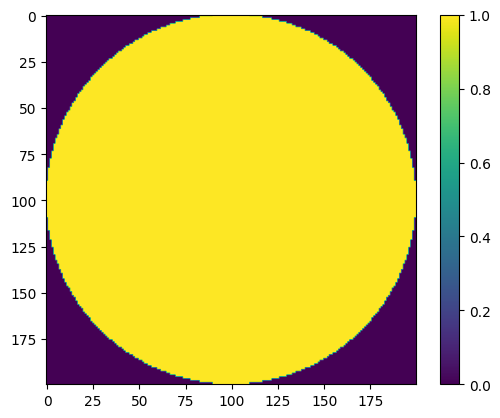

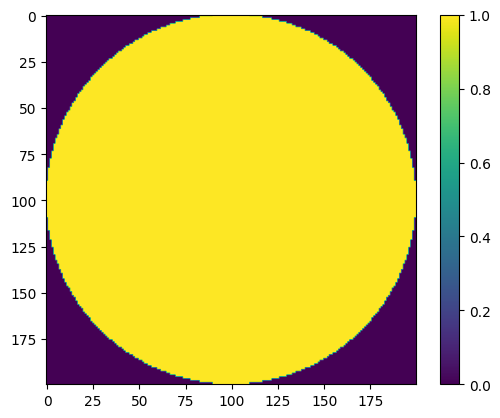

In [3]:
# create the Telescope object for OOPAO
tel = Telescope(resolution = 200, diameter = 10, centralObstruction = 0, samplingTime=0.1)

plt.imshow(tel.pupil)
plt.colorbar()
plt.show()

pupil_test = mask_circle(200, 100, center=(0,0), centered=True)

# mask_circle(N, r, center=(0,0), centered=True)
# creates a circular pupil mask
# N represents the number of pixels for both the x and y directions
# r represents the radius of the circular pupil in pixels

plt.imshow(pupil_test)
plt.colorbar()
plt.show()

In [4]:
D = 10.0 # [m]
resolution = 200 # telescope resolution (pupil sampling)

ang_pixel_Nyquist_rad = 0.5*(1.654e-06)/D

pixel_size = 18e-6 # [m]
ang_pixel = ang_pixel_Nyquist_rad*206264806.71915 # [mas]
print(ang_pixel)
f = pixel_size / ang_pixel * 206264806.71915 # [m]
print(f)

# Let's imagine we have DITs (detector integration times) of 10 frames with a total of 1 second exposure
# This is to generate a synthetic PSF 
sampling_time = 0.1 # [s]
num_samples = 10

# If the number of pixels in image is odd, the code will automatically center generated PSFs it to one pixel in the middle
tel_A = Telescope_A(img_resolution        = 10,  # img_resolution - Sampling of the telescope's PSF
                    pupil             = mask_circle(resolution, resolution/2, center=(0,0), centered=True),
                    diameter          = D,
                    focalLength       = f,
                    pupilReflectivity = 1.0,
                    gpu_flag          = False)


print("Telescope's pupil area = {} [m^2]".format(tel_A.area))

det_A = Detector_A(pixel_size     = pixel_size,
                sampling_time = sampling_time,
                samples       = num_samples,
                RON           = 0.0, # used to generate PSF or the synthetic R_n [photons]
                QE            = 0.7) # not used

det_A.object = None
det_A * tel_A
ngs_A = Source_A([('H', 18.0)]) # Initialize a target of H_mag=10
ngs_A * tel_A # attach the source to the telescope

17.058099515673703
217.65417170495772
-------------------- TELESCOPE --------------------
Diameter 			10.0 	 [m]
Pupil sampling 			200 	 [pix]
------------------------------------------------
Telescope's pupil area = 78.53981633974483 [m^2]


In [5]:
# Source and Zernike base for OOPAO
src = Source(optBand = 'H', magnitude = 18)
src*tel

##%% -----------------------     ZERNIKE    ----------------------------------
nModes = 10               # number of zernike to compute

#create a zernike object
Z = Zernike(telObject = tel, J = nModes)

# compute the zernike polynomials associated to the telescope tel
Z.computeZernike(tel)

%%%%%%%%%%%%%%%%%%%%%%%%%%%%% SOURCE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
 Source Wavelength Zenith  Azimuth   Altitude Magnitude    Flux   
           [m]    [arcsec]  [deg]      [m]              [phot/m2/s]
-------------------------------------------------------------------
  NGS   1.654e-06    0        0        inf       18.0     180.0   
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%


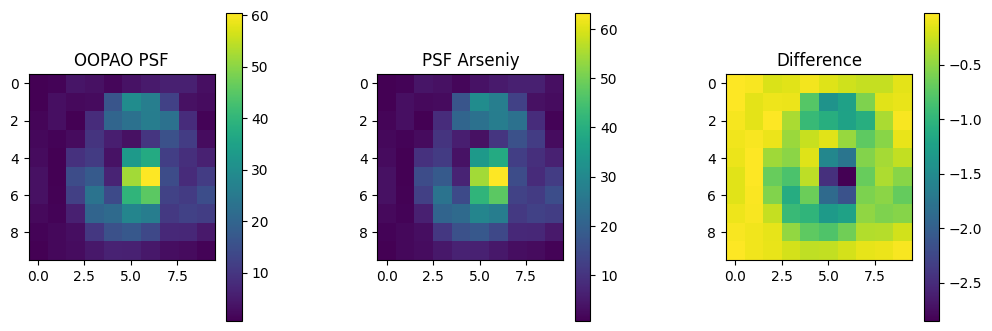

In [6]:
def PSFfromCoefs(coefs,zeroPaddingFactor,oversampling,img_resolution):

    aux = coefs.copy()
    aux[3] += diversity_OPD # adding phase diversity (astigmatism)
    tel.OPD = np.squeeze(Z.modesFullRes@aux)
    
    tel.computePSF(zeroPaddingFactor)
    PSF_cropped = extractor(tel.PSF,img_resolution*oversampling)
    PSF_binned_cropped = bin_ndarray(PSF_cropped,(img_resolution,img_resolution),'sum')

    tel.OPD *= 0

    return PSF_binned_cropped

def PSFfromCoefs_A(coefs):
    tel_A.src.OPD = Z_basis_A.wavefrontFromModes(tel_A,coefs) + OPD_diversity
    PSF = tel_A.ComputePSF()
    tel_A.src.OPD *= 0.0 # zero out just in case
    return PSF

# Initialize modal basis
Z_basis_A = Zernike_A(modes_num = 10)
Z_basis_A.computeZernike(tel_A)

diversity_shift = 200e-9 #[m]
OPD_diversity = Z_basis_A.Mode(3)*diversity_shift
diversity_OPD = 200e-9

coefs_0 = np.random.uniform(-300, 300, 10)*1e-9 # [m]  random coefficients

make_3_plot_graph(PSFfromCoefs(coefs_0,4,2,10),"OOPAO PSF",PSFfromCoefs_A(coefs_0),"PSF Arseniy",\
                  PSFfromCoefs(coefs_0,4,2,10)-PSFfromCoefs_A(coefs_0),"Difference")

In [7]:
PSF_OOPAO = PSFfromCoefs(coefs_0,4,2,10)
PSF_A = PSFfromCoefs_A(coefs_0)

estimator = LIFT_OOPAO(telescope=tel, modeBasis=Z, zeroPaddingFactor=4, oversampling=2, img_resolution=10, \
                       diversity_OPD=diversity_OPD, iterations=20, readoutnoise=0.0, object = None)

estimator_A = LIFT_A(tel_A, Z_basis_A, OPD_diversity, 20)

modes = [0,1,2,3,4,5,6,7,8,9]

# OOPAO
coefs_1, PSF_1, _ = estimator.Reconstruct(PSF_OOPAO, R_n='model', mode_ids=modes, verbous=True, optimize_norm='sum')
# Arseniy
coefs_1_A, PSF_1_A, _A = estimator_A.Reconstruct(PSF_A, R_n='model', mode_ids=modes, verbous=True, optimize_norm='sum')

Criterion: 0.0
Mode # 0 -1.6253
Mode # 1 67.9797
Mode # 2 12.6647
Mode # 3 164.0939
Mode # 4 -42.5939
Mode # 5 75.8897
Mode # 6 -21.4375
Mode # 7 24.6713
Mode # 8 19.2101
Mode # 9 55.3024

Criterion: 0.8598123348330844
Mode # 0 -26.5351
Mode # 1 67.1339
Mode # 2 -32.6999
Mode # 3 89.9703
Mode # 4 -93.0173
Mode # 5 -103.1365
Mode # 6 60.0052
Mode # 7 8.8503
Mode # 8 -76.1558
Mode # 9 -39.662

Criterion: 0.3471614661327763
Mode # 0 12.7986
Mode # 1 18.8289
Mode # 2 45.3973
Mode # 3 -39.7075
Mode # 4 13.0193
Mode # 5 83.194
Mode # 6 -2.4977
Mode # 7 -36.4947
Mode # 8 47.7018
Mode # 9 32.4809

Criterion: 0.3704977330714367
Mode # 0 0.6652
Mode # 1 -5.4335
Mode # 2 -18.5382
Mode # 3 -17.727
Mode # 4 -71.1013
Mode # 5 -30.8941
Mode # 6 -2.308
Mode # 7 -15.2152
Mode # 8 -15.0983
Mode # 9 9.0877

Criterion: 0.23897079523742557
Mode # 0 13.051
Mode # 1 24.1929
Mode # 2 12.1051
Mode # 3 -27.2828
Mode # 4 -51.9135
Mode # 5 19.8896
Mode # 6 -7.4483
Mode # 7 -12.9596
Mode # 8 25.6924
Mode # 9 15.74

In [10]:
print('Initial coefficients')
print(coefs_0)

print('Retreived coefficients using OOPAO')
print(coefs_1)

print('Retrieved coefficients using Arseniy')
print(coefs_1_A)

print('Relative error')
print(np.abs(coefs_1-coefs_1_A)/(coefs_1_A)*100)

Initial coefficients
[ 6.75056288e-09  2.03216426e-07 -6.85602704e-08 -9.91639089e-08
  3.05821201e-08 -7.80961912e-08 -2.19929301e-07 -1.78779958e-08
 -9.92610567e-08  1.38800353e-07]
Retreived coefficients using OOPAO
[-3.5347707e-06 -3.4426287e-06 -5.1459815e-06 -4.5883112e-06
 -1.3017928e-05 -7.6824182e-07  5.3573638e-07  3.8619410e-07
 -8.0446480e-06  4.9703408e-06]
Retrieved coefficients using Arseniy
[ 3.7090131e-06  5.8317582e-06 -1.1031957e-06  1.7660377e-06
 -2.6247944e-06 -7.5041510e-07 -1.2388839e-06  1.9165591e-06
 -2.0906916e-06 -8.3901051e-07]
Relative error
[ 195.30219    159.03242   -366.46133    359.80823   -395.9599
   -2.3755813 -143.24347     79.84961   -284.78406   -692.4051   ]


## More comparison tests

Initial coefficients
[-1.30857490e-07  3.61625596e-07  2.47346318e-07 -1.75211240e-07
  1.69799882e-07  8.21493823e-08  5.23171743e-08 -3.50502559e-07
  3.78096542e-07  1.25806912e-07]
Retreived coefficients using OOPAO
[-5.5199449e-09  2.1751674e-07  2.3350935e-08  3.2343323e-08
 -2.9359893e-07  4.8331863e-08 -2.8301249e-08 -1.3530540e-07
  8.8618599e-08  2.3525265e-08]
Retrieved coefficients using Arseniy
[-5.5199463e-09  2.1751674e-07  2.3350937e-08  3.2343333e-08
 -2.9359890e-07  4.8331867e-08 -2.8301244e-08 -1.3530540e-07
  8.8618584e-08  2.3525269e-08]
Relative error
[-2.4135517e-05  0.0000000e+00  7.6072183e-06  3.2953132e-05
 -9.6804552e-06  7.3506653e-06 -1.8829811e-05 -0.0000000e+00
  1.6035976e-05  1.5101692e-05]
RMSE OOPAO: 0.8431926222954166
RMSE Arseniy: 0.8431926065685065


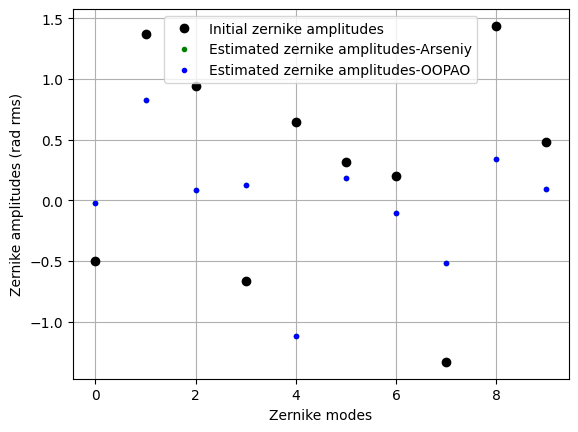

Initial coefficients
[-3.27986675e-07  3.37464963e-07 -2.85074238e-08 -1.44020867e-08
 -2.34500472e-07 -2.20328374e-07  2.12018905e-07  3.02881705e-07
  1.16397171e-08 -3.05587691e-08]
Retreived coefficients using OOPAO
[-3.4827806e-07  4.6989118e-07 -2.2149628e-07 -1.5234204e-09
  2.4337220e-07  4.0375053e-08 -7.5410647e-08 -7.2226371e-08
 -2.3390974e-07  1.3145339e-07]
Retrieved coefficients using Arseniy
[-3.4828057e-07  4.6988325e-07 -2.2150112e-07 -1.5197689e-09
  2.4338070e-07  4.0377017e-08 -7.5424204e-08 -7.2229078e-08
 -2.3390552e-07  1.3144538e-07]
Relative error
[-0.00071813  0.00168758 -0.00218775 -0.24026835  0.00349169  0.00486576
 -0.01797454 -0.00374803 -0.00180441  0.00609753]
RMSE OOPAO: 0.9770714355967133
RMSE Arseniy: 0.9770819747509244


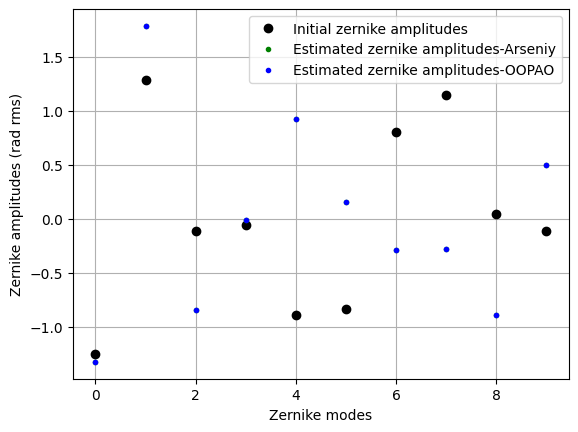

Initial coefficients
[ 9.29117634e-08  1.32900232e-07 -1.71396689e-08 -1.33150017e-07
  2.27856842e-07  3.13877689e-07 -2.76761530e-09 -3.16999199e-08
  1.63324664e-07  2.17880166e-07]
Retreived coefficients using OOPAO
[ 3.4485463e-08 -4.6191417e-08 -3.5412782e-08  2.8375990e-07
  2.1470346e-07  3.9386642e-08  2.5555556e-08  3.6218395e-08
 -2.3292305e-08  7.9816196e-08]
Retrieved coefficients using Arseniy
[ 3.4486291e-08 -4.6193080e-08 -3.5413056e-08  2.8376101e-07
  2.1469734e-07  3.9387629e-08  2.5556325e-08  3.6218481e-08
 -2.3296751e-08  7.9816076e-08]
Relative error
[ 0.00240032 -0.00359939 -0.00077248  0.00039063  0.0028528   0.00250752
  0.00300968  0.00023542 -0.01908516  0.00015134]
RMSE OOPAO: 0.70503616293671
RMSE Arseniy: 0.705039019167376


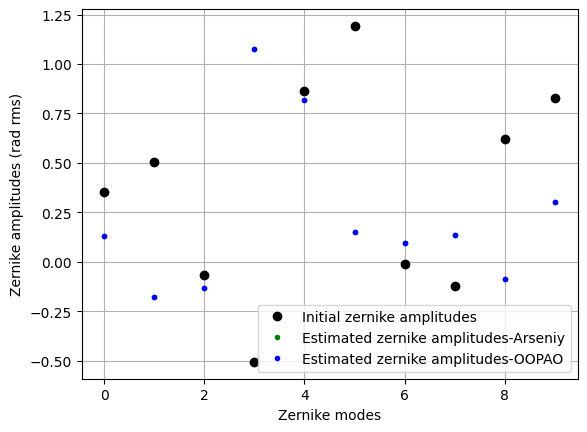

Initial coefficients
[ 2.08727151e-07  2.03080243e-07  2.20684638e-07 -3.94390039e-07
  8.04646470e-08  2.53533863e-07 -3.87097670e-07  1.93860066e-07
 -3.30877899e-07 -2.77294972e-07]
Retreived coefficients using OOPAO
[ 1.7310751e-07 -2.3305322e-09 -4.3062347e-08  4.0279349e-07
 -2.2743453e-07  5.6756107e-08  1.6675598e-07  9.3986380e-08
  1.3900963e-07  4.4752642e-08]
Retrieved coefficients using Arseniy
[ 1.7310649e-07 -2.3295006e-09 -4.3062162e-08  4.0279431e-07
 -2.2743373e-07  5.6754700e-08  1.6675536e-07  9.3986010e-08
  1.3900805e-07  4.4752341e-08]
Relative error
[ 0.00059107 -0.044285   -0.00042901  0.00020463 -0.00034991  0.00247887
  0.00037497  0.00039312  0.00113476  0.00067478]
RMSE OOPAO: 1.482638547944075
RMSE Arseniy: 1.482637870749361


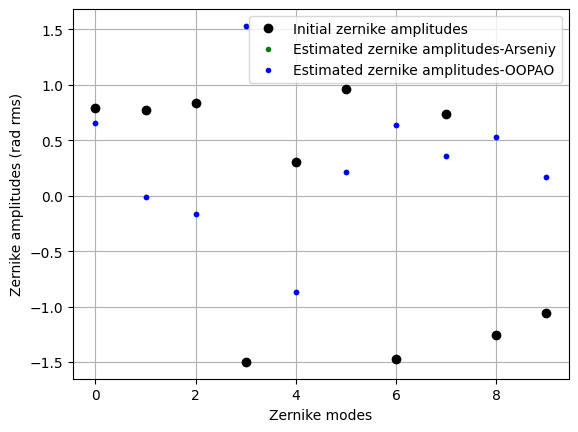

Initial coefficients
[-1.44240444e-07 -3.59480150e-07 -3.90237410e-07  1.88745080e-07
  2.46081835e-07  1.75131539e-07  8.46645138e-08 -2.03630632e-07
 -3.73425865e-07  1.66180371e-08]
Retreived coefficients using OOPAO
[-1.7830159e-07 -1.9912277e-07 -1.0020878e-07 -3.8868556e-08
  3.7621331e-07  1.9028485e-08  9.7776498e-09  3.3868950e-08
  8.6063331e-08 -3.5550038e-08]
Retrieved coefficients using Arseniy
[-1.7903626e-07 -2.0036464e-07 -1.0032159e-07 -3.7202319e-08
  3.7654993e-07  1.9300368e-08  1.0112265e-08  3.2976377e-08
  8.5805169e-08 -3.5753068e-08]
Relative error
[-0.4103486  -0.6198062  -0.11245124 -4.4788523   0.08939763  1.4086885
  3.3090014   2.7067046   0.3008694  -0.56786865]
RMSE OOPAO: 0.8322432537020611
RMSE Arseniy: 0.8306347228947883


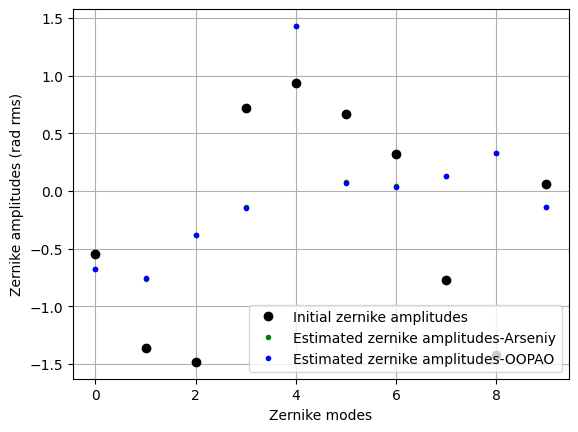

Initial coefficients
[ 2.34926261e-07 -3.67035969e-07 -3.78378765e-07  3.68814235e-07
 -1.36346813e-07  3.64669537e-10  3.09035482e-07  1.07958944e-07
 -3.45009473e-07 -3.92631840e-07]
Retreived coefficients using OOPAO
[-4.5837012e-07 -6.0912839e-07  2.8486448e-07  3.5170501e-07
 -3.5692733e-07  2.7255904e-08  1.7598888e-08  2.3484289e-07
 -4.4520018e-08 -3.4667938e-08]
Retrieved coefficients using Arseniy
[-4.5833417e-07 -6.0919774e-07  2.8493017e-07  3.5171939e-07
 -3.5700091e-07  2.7211934e-08  1.7600511e-08  2.3489655e-07
 -4.4487564e-08 -3.4673874e-08]
Relative error
[-0.00784438 -0.01138366  0.02305217  0.00408888 -0.02061166  0.16158411
  0.00922468  0.02284418 -0.07295081 -0.0171212 ]
RMSE OOPAO: 1.3948818688480027
RMSE Arseniy: 1.3949483045025755


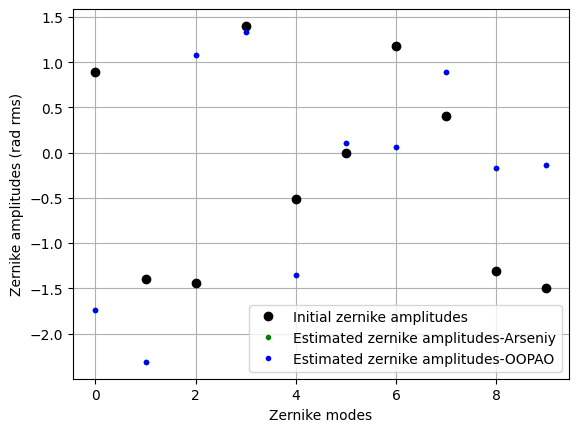

Initial coefficients
[ 9.71752630e-08  3.93522404e-07 -3.27079496e-07 -3.17262491e-08
 -2.67421757e-07  2.12659181e-07 -1.13028193e-07  3.78864015e-08
 -2.28792666e-08  2.01251293e-07]
Retreived coefficients using OOPAO
[ 9.8906812e-06 -7.9072070e-06 -4.2378774e-06  9.1835418e-06
  1.6996275e-06 -1.4445611e-06  9.0067864e-08 -1.4532733e-06
 -3.1481859e-06  1.2613100e-06]
Retrieved coefficients using Arseniy
[ 7.8468274e-06 -6.7539995e-06 -2.8172133e-06  7.6736678e-06
 -2.4540205e-08 -2.8767415e-06  2.3596947e-06 -1.2419306e-06
 -2.8766783e-06 -5.4606147e-07]
Relative error
[   26.04688    -17.074438   -50.427998    19.67604  -7025.8896
   -49.784813    96.18307    -17.017271    -9.438232  -330.98315 ]
RMSE OOPAO: 20.27290391285914
RMSE Arseniy: 17.10617966442525


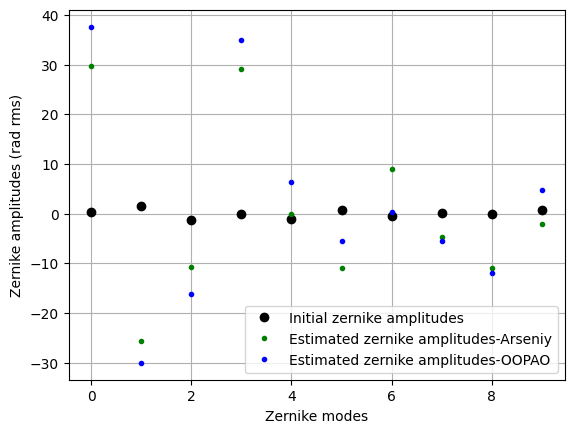

Initial coefficients
[ 1.29840293e-07  1.78999349e-07 -5.91868302e-08 -2.95447115e-07
  1.10707059e-07  1.11159905e-07 -2.33329577e-07 -7.89192403e-08
  2.31251300e-07  3.32814870e-07]
Retreived coefficients using OOPAO
[-1.2422848e-06  9.2379884e-07 -1.5281710e-06 -1.5518934e-06
 -2.0634709e-06 -7.9101079e-07 -5.6268129e-07 -9.3200265e-07
 -1.1823223e-07  3.0547395e-07]
Retrieved coefficients using Arseniy
[-1.6999738e-06  7.1164339e-07 -1.7648296e-06 -1.8310432e-06
 -2.2163863e-06 -8.5400450e-07 -6.9720932e-07 -1.0461700e-06
 -7.5509078e-08  2.8342737e-07]
Relative error
[-26.923296   29.812044  -13.409715  -15.245393   -6.8993115  -7.3762736
 -19.295212  -10.91289   -56.58015     7.7785635]
RMSE OOPAO: 4.2766418533924355
RMSE Arseniy: 4.87864878207137


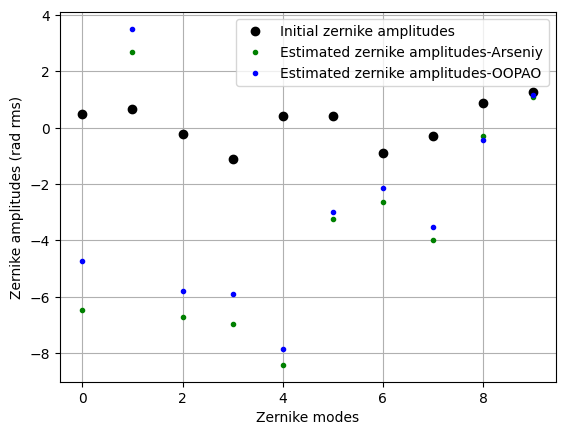

Initial coefficients
[-3.72094348e-07 -1.51630327e-07 -7.01432874e-08 -2.83073764e-07
  3.61921216e-07 -1.57664359e-07 -9.04193580e-08  3.30370897e-07
 -3.12936192e-07  7.77863767e-08]
Retreived coefficients using OOPAO
[-4.56125150e-07 -1.12994556e-07 -8.21588770e-08  2.11351249e-07
  3.51643763e-07 -7.35365617e-08  1.35970772e-08 -1.86880712e-07
 -1.72528871e-08  2.23423555e-08]
Retrieved coefficients using Arseniy
[-4.56125207e-07 -1.12994606e-07 -8.21588699e-08  2.11351278e-07
  3.51643820e-07 -7.35365546e-08  1.35970701e-08 -1.86880726e-07
 -1.72529102e-08  2.23423395e-08]
Relative error
[-1.2462240e-05 -4.4018023e-05 -8.6483997e-06  1.3447617e-05
  1.6165057e-05 -9.6624426e-06  5.2257048e-05 -7.6042375e-06
 -1.3384779e-04  7.1555674e-05]
RMSE OOPAO: 0.9528877709703455
RMSE Arseniy: 0.9528878020565101


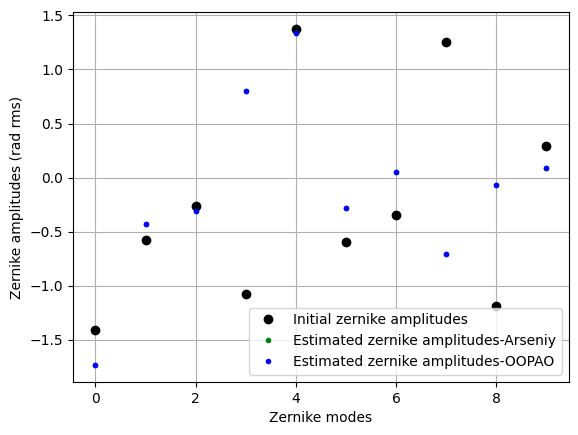

Initial coefficients
[-9.70584212e-08 -3.40668803e-07  1.75603591e-08 -1.50570686e-07
 -1.49354961e-07 -3.31512113e-07 -1.77712416e-07 -3.29282600e-07
 -2.57206236e-07 -1.53171801e-07]
Retreived coefficients using OOPAO
[ 2.3623038e-08 -3.7854210e-07 -2.4051257e-08  3.6958062e-07
  1.7615733e-07 -1.4572403e-07  4.9099626e-08 -2.2648882e-08
  8.7147598e-08 -1.2479305e-10]
Retrieved coefficients using Arseniy
[ 2.3623162e-08 -3.7854176e-07 -2.4051143e-08  3.6958042e-07
  1.7615787e-07 -1.4572409e-07  4.9099540e-08 -2.2648887e-08
  8.7147484e-08 -1.2464320e-10]
Relative error
[ 5.2636891e-04 -9.0098518e-05 -4.7268785e-04  5.3831849e-05
  3.0655030e-04 -3.9007566e-05  1.7365770e-04 -2.3529061e-05
  1.3045338e-04 -1.2022506e-01]
RMSE OOPAO: 1.0166506143841187
RMSE Arseniy: 1.0166506538592546


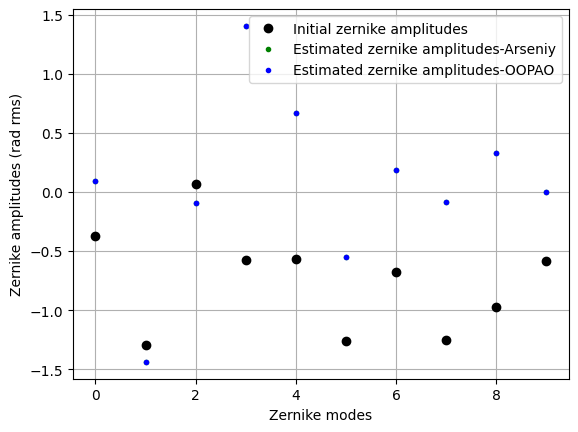

Initial coefficients
[ 9.30190110e-08  3.76273791e-07 -1.42621539e-07 -2.71353755e-07
 -8.54446115e-08 -3.80793431e-07  3.78035061e-07 -1.94691089e-07
  2.06307610e-07 -1.41483098e-07]
Retreived coefficients using OOPAO
[-4.8581992e-08  1.9098175e-06 -4.3308458e-07  5.0522850e-08
  6.6531618e-07 -4.9472220e-07  8.9031676e-07 -1.1084051e-06
  3.1564267e-07  1.0939411e-07]
Retrieved coefficients using Arseniy
[-7.2698361e-07  2.1247599e-06 -4.4078101e-07  3.8436272e-07
  3.6815391e-07 -4.8283931e-07  4.7310505e-07 -6.8515516e-07
  5.7209422e-07  2.9985864e-07]
Relative error
[-93.31732    10.116083   -1.746089   86.85542    80.71686    -2.4610443
  88.18585   -61.774315   44.826805   63.51811  ]
RMSE OOPAO: 2.49351808322128
RMSE Arseniy: 2.697619906715259


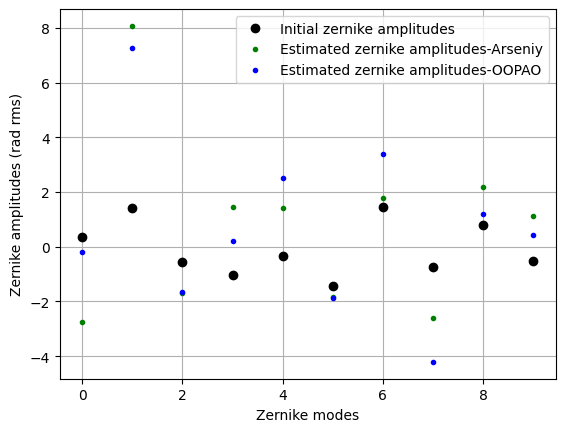

Initial coefficients
[-1.90441319e-07  2.43360785e-07  8.82479761e-08 -8.31537494e-08
 -9.76574725e-08 -1.08979425e-07  3.21782158e-07 -3.46300777e-07
  4.62730742e-08 -1.56415846e-07]
Retreived coefficients using OOPAO
[ 1.3598004e-06 -1.4460081e-06 -1.8088700e-06 -5.1096531e-06
  2.9956655e-06  5.8776077e-06 -1.8863255e-06 -3.5039589e-06
  4.1154931e-07  2.0965032e-07]
Retrieved coefficients using Arseniy
[-1.0724179e-05 -3.6933984e-06 -5.9066401e-06  1.4707113e-05
  2.1550490e-07  3.5843620e-06  2.4305414e-06 -2.8830227e-06
  5.7613533e-06 -1.4993769e-06]
Relative error
[-112.679756  -60.848843  -69.37565   134.74272  1290.0684     63.979183
  177.60928   -21.537678   92.85673  -113.9825  ]
RMSE OOPAO: 11.686662340260174
RMSE Arseniy: 25.20499004611016


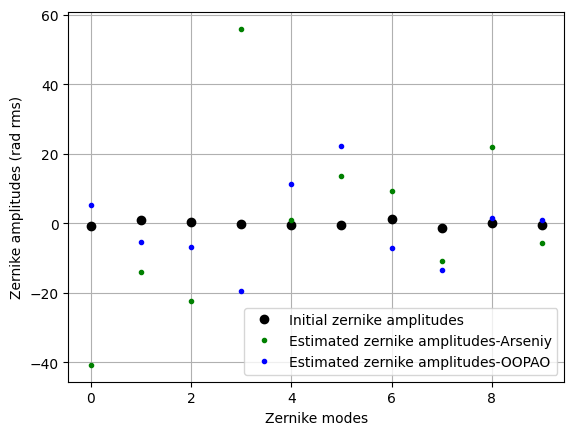

Initial coefficients
[ 3.30601914e-07  1.61074528e-07  3.98759324e-07 -1.40518550e-07
  1.77759677e-07 -1.92807456e-07  2.17238044e-07  3.08947967e-07
  5.48576638e-08 -1.06705999e-07]
Retreived coefficients using OOPAO
[-2.33426540e-08  2.28151421e-07 -1.35718309e-07  2.37072854e-07
  1.20459775e-08  2.85033632e-08  5.67439287e-08 -1.55663145e-07
  7.74355797e-08  7.81185818e-08]
Retrieved coefficients using Arseniy
[-2.3343057e-08  2.2815449e-07 -1.3571635e-07  2.3707140e-07
  1.2048231e-08  2.8502877e-08  5.6743481e-08 -1.5566371e-07
  7.7433810e-08  7.8121396e-08]
Relative error
[-0.00172742  0.00134538 -0.001445    0.00061142  0.0187024   0.00170762
  0.00078889 -0.00036517  0.00228486  0.00360177]
RMSE OOPAO: 1.1464198493429458
RMSE Arseniy: 1.1464187030402575


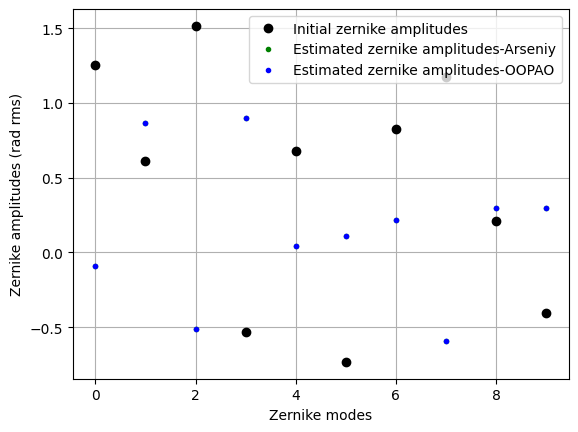

Initial coefficients
[ 3.07065926e-07 -1.23543507e-07 -3.54101200e-07 -2.39419878e-07
 -2.77623452e-07 -3.44586546e-07  1.54392304e-07 -3.14930132e-07
 -1.65987200e-07 -3.08956336e-07]
Retreived coefficients using OOPAO
[ 1.7247979e-07  1.8032905e-07 -3.7154276e-08  2.1765058e-07
 -1.0248757e-07 -1.9426083e-07  2.6328280e-07  2.2475581e-07
  8.8939593e-08  1.0650536e-08]
Retrieved coefficients using Arseniy
[ 1.7247996e-07  1.8032972e-07 -3.7153274e-08  2.1765091e-07
 -1.0248688e-07 -1.9426105e-07  2.6328328e-07  2.2475598e-07
  8.8939871e-08  1.0650356e-08]
Relative error
[ 9.8869612e-05  3.7038274e-04 -2.6965733e-03  1.5017152e-04
 -6.7250209e-04 -1.0973009e-04  1.8351681e-04  7.5873519e-05
  3.1157193e-04  1.6845637e-03]
RMSE OOPAO: 1.166755162701236
RMSE Arseniy: 1.1667562704102132


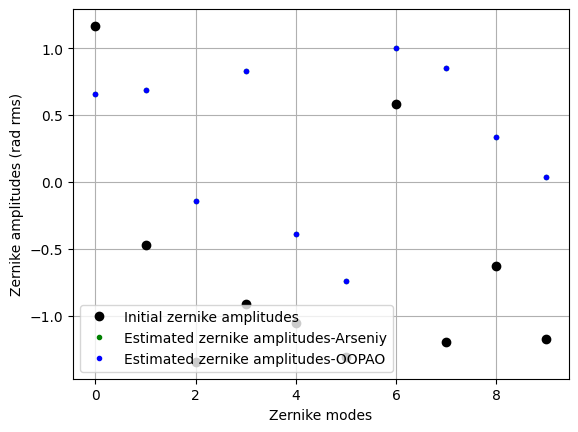

Initial coefficients
[-1.04823350e-07 -1.00678525e-07 -1.89365005e-07  1.33482540e-07
  4.64641432e-08 -3.63039500e-07 -2.51485340e-07  2.80714724e-07
  9.20128067e-08  1.42190999e-07]
Retreived coefficients using OOPAO
[-5.6312086e-07 -1.3654443e-07  1.4287725e-07  4.6374777e-07
 -5.0543832e-07 -9.9971473e-08 -4.6542755e-08  2.7903337e-08
 -3.2177983e-08  1.4906448e-08]
Retrieved coefficients using Arseniy
[-5.6311973e-07 -1.3654254e-07  1.4287704e-07  4.6374745e-07
 -5.0543707e-07 -9.9971508e-08 -4.6542848e-08  2.7903834e-08
 -3.2177461e-08  1.4906846e-08]
Relative error
[-2.0188749e-04 -1.3842160e-03  1.4919319e-04  6.7415742e-05
 -2.4742054e-04 -3.5537261e-05 -1.9846347e-04  1.7824789e-03
 -1.6230271e-03  2.6692699e-03]
RMSE OOPAO: 1.1659995628862598
RMSE Arseniy: 1.1659973984428431


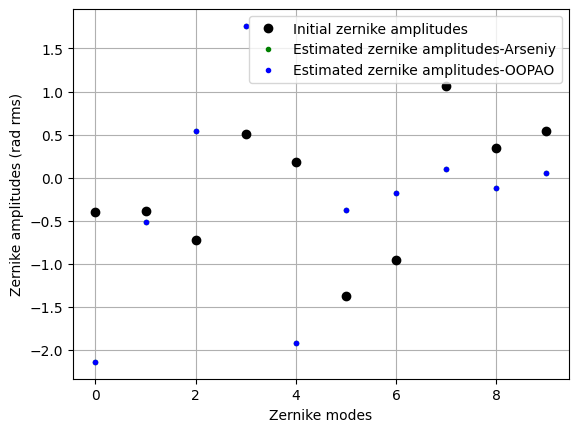

Initial coefficients
[-1.14924860e-07  3.76699490e-07 -2.10478298e-07 -2.05268459e-07
 -3.42532036e-07 -3.81133556e-09  1.75491484e-08  3.84453795e-07
 -2.50712550e-07  2.69431404e-07]
Retreived coefficients using OOPAO
[-6.4299275e-06  6.4906867e-06 -3.7501663e-06  4.4110343e-06
 -2.6886525e-07  1.4089754e-06 -8.4911721e-07  3.8131776e-07
  7.2507595e-07 -2.8387609e-07]
Retrieved coefficients using Arseniy
[-1.7739466e-06  1.9820563e-06 -1.2952319e-06  1.4353253e-06
 -5.4278712e-07  5.4875505e-07 -3.1752643e-07  2.4602105e-08
  8.1989207e-08 -2.6573863e-07]
Relative error
[-262.46454   227.47235  -189.5363    207.31947   -50.465805  156.75853
 -167.41624  1449.9396    784.3554     -6.825299]
RMSE OOPAO: 12.888487662862236
RMSE Arseniy: 3.8332062926956723


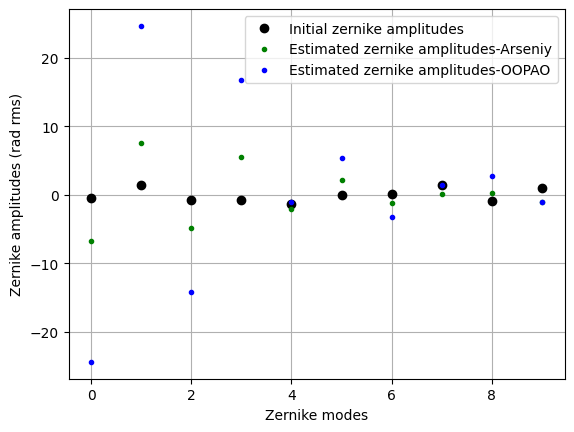

Initial coefficients
[ 3.43725815e-07  3.14628855e-07 -1.88855807e-07  3.87513834e-07
 -1.07198032e-08  2.84343134e-07  1.62366269e-07  2.86403146e-07
 -2.57371223e-07  3.35870048e-07]
Retreived coefficients using OOPAO
[-3.1720489e-07  8.1231315e-07  4.2327596e-08  5.1024358e-07
  7.2159889e-07 -1.4605327e-07  2.2686720e-07 -2.4942582e-07
  4.1252310e-08 -1.4196623e-07]
Retrieved coefficients using Arseniy
[-3.2015259e-07  8.1406716e-07  4.3230678e-08  5.1173186e-07
  7.2119030e-07 -1.4571533e-07  2.2857711e-07 -2.5002760e-07
  4.2091308e-08 -1.4156001e-07]
Relative error
[-0.9207174   0.21546347  2.0889843   0.2908309   0.05665502 -0.23191392
  0.74806565 -0.24068257  1.9932814  -0.28695768]
RMSE OOPAO: 1.7338998288688652
RMSE Arseniy: 1.7366164906211274


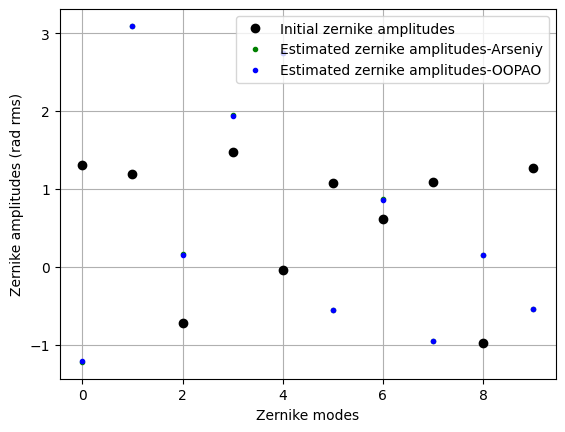

Initial coefficients
[-1.31935762e-07  7.00481211e-08 -3.89215786e-07 -3.16995008e-07
  3.46439581e-07  3.04123212e-07  1.15543896e-07 -1.75695812e-07
  2.16738138e-07 -1.05002945e-07]
Retreived coefficients using OOPAO
[-2.1231575e-07 -3.1046940e-07  1.5162787e-07 -4.0657493e-08
 -1.5915919e-07  1.7605714e-07  7.9883932e-08 -1.4363249e-07
  1.6866555e-07  7.7221259e-08]
Retrieved coefficients using Arseniy
[-2.1231543e-07 -3.1046841e-07  1.5162848e-07 -4.0657692e-08
 -1.5915982e-07  1.7605757e-07  7.9883989e-08 -1.4363255e-07
  1.6866565e-07  7.7221351e-08]
Relative error
[-1.5394531e-04 -3.2040614e-04  4.0300260e-04 -4.8933411e-04
 -4.0179011e-04  2.4215128e-04  7.1157461e-05 -3.9575585e-05
  5.8978214e-05  1.1961789e-04]
RMSE OOPAO: 1.0944027508069798
RMSE Arseniy: 1.0944029413168341


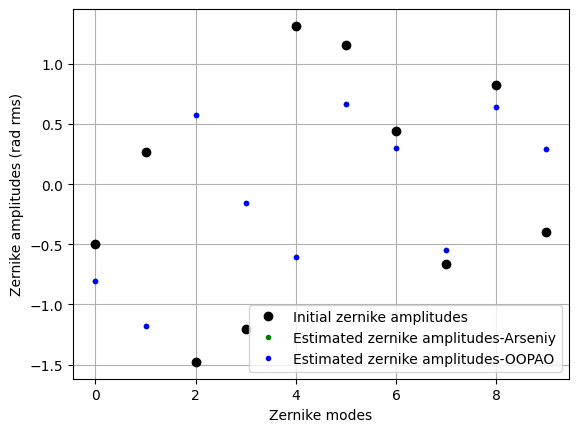

Initial coefficients
[ 1.27069346e-07  1.36481300e-07 -1.93989518e-07 -2.94270991e-07
  2.95334699e-08 -2.41232631e-07  7.49304431e-08  3.07876750e-09
 -3.94160507e-07  1.87077147e-08]
Retreived coefficients using OOPAO
[ 1.5100602e-07  1.0532044e-07 -1.6532742e-07  3.0211413e-07
  2.7891167e-07 -1.2727155e-07  4.8722505e-08 -4.2166089e-08
 -3.6491443e-08 -3.9398760e-08]
Retrieved coefficients using Arseniy
[ 1.5100609e-07  1.0532028e-07 -1.6532746e-07  3.0211419e-07
  2.7891170e-07 -1.2727155e-07  4.8722516e-08 -4.2166086e-08
 -3.6491425e-08 -3.9398749e-08]
Relative error
[ 4.7053913e-05  1.4842289e-04 -2.5786741e-05  1.8815210e-05
  1.0190218e-05 -0.0000000e+00  2.1875187e-05 -8.4255244e-06
 -4.8678747e-05 -2.7051979e-05]
RMSE OOPAO: 0.9047601272353856
RMSE Arseniy: 0.9047602149092766


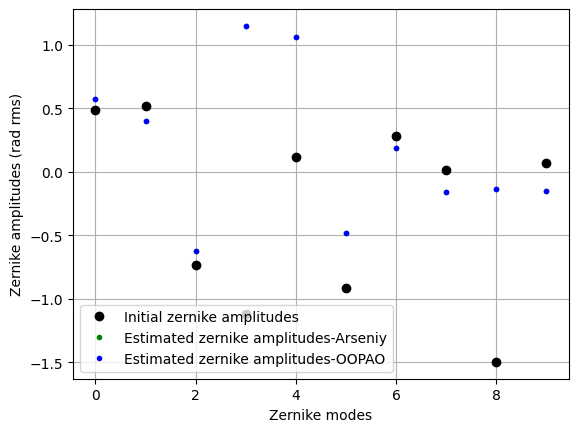

Initial coefficients
[ 2.95288664e-07 -1.27250917e-07 -2.90836643e-07  6.46516694e-09
 -3.30954043e-07 -2.50747508e-08 -3.46660058e-07  3.59816074e-07
 -5.27091786e-08 -3.71686136e-09]
Retreived coefficients using OOPAO
[-3.5347707e-06 -3.4426287e-06 -5.1459815e-06 -4.5883112e-06
 -1.3017928e-05 -7.6824182e-07  5.3573638e-07  3.8619410e-07
 -8.0446480e-06  4.9703408e-06]
Retrieved coefficients using Arseniy
[ 3.7090131e-06  5.8317582e-06 -1.1031957e-06  1.7660377e-06
 -2.6247944e-06 -7.5041510e-07 -1.2388839e-06  1.9165591e-06
 -2.0906916e-06 -8.3901051e-07]
Relative error
[ 195.30219    159.03242   -366.46133    359.80823   -395.9599
   -2.3755813 -143.24347     79.84961   -284.78406   -692.4051   ]
RMSE OOPAO: 21.531044198756963
RMSE Arseniy: 9.66845980216491


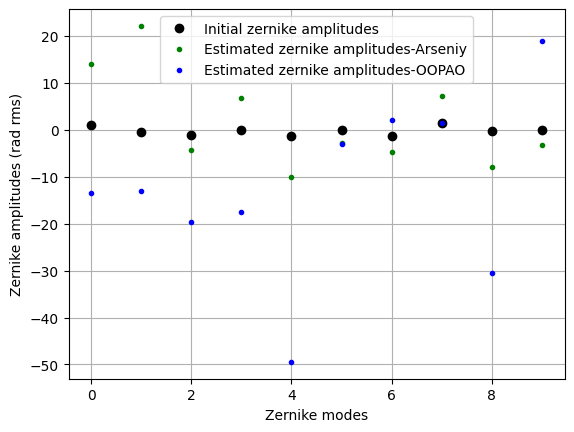

In [9]:
modes = [0,1,2,3,4,5,6,7,8,9]

number_modes = len(modes)

for i in range(20):

    coefs_def = np.random.uniform(-400, 400, 10)*1e-9 # [m]  random coefficients
    
    # Arseniy
    OPD_diversity = Z_basis_A.Mode(3)*200*1e-9
    PSF_A = PSFfromCoefs_A(coefs_def)
    # OOPAO
    diversity_OPD = 200*1e-9
    PSF_OOPAO = PSFfromCoefs(coefs_def,4,2,10)

    estimator = LIFT_OOPAO(telescope=tel, modeBasis=Z, zeroPaddingFactor=4, oversampling=2, img_resolution=10, \
                       diversity_OPD=diversity_OPD, iterations=20, readoutnoise=0.0, object = None)

    estimator_A = LIFT_A(tel_A, Z_basis_A, OPD_diversity, 20)

    # OOPAO
    coefs_1, PSF_1, _ = estimator.Reconstruct(PSF_OOPAO, R_n='model', mode_ids=modes, verbous=False, optimize_norm='sum')
    # Arseniy
    coefs_1_A, PSF_1_A, _A = estimator_A.Reconstruct(PSF_A, R_n='model', mode_ids=modes, verbous=False, optimize_norm='sum')

    print('Initial coefficients')
    print(coefs_def)
    
    print('Retreived coefficients using OOPAO')
    print(coefs_1)
    
    print('Retrieved coefficients using Arseniy')
    print(coefs_1_A)
    
    print('Relative error')
    print(np.abs(coefs_1-coefs_1_A)/(coefs_1_A)*100)

    k = 2*np.pi/src.wavelength
    coefs_1_rad = coefs_1*k
    coefs_1_A_rad = coefs_1_A*k
    coefs_def_rad = coefs_def*k

    sigma_c_OOPAO = np.sqrt(np.sum((coefs_1_rad - coefs_def_rad)**2)/(number_modes))
    sigma_c_Arseniy = np.sqrt(np.sum((coefs_1_A_rad - coefs_def_rad)**2)/(number_modes))

    print("RMSE OOPAO: {}".format(sigma_c_OOPAO))
    print("RMSE Arseniy: {}".format(sigma_c_Arseniy))

    plt.plot(np.arange(number_modes),coefs_def_rad[:number_modes],"ko",label="Initial zernike amplitudes")
    plt.plot(np.arange(number_modes),coefs_1_A_rad[:number_modes],"g.",label="Estimated zernike amplitudes-Arseniy")
    plt.plot(np.arange(number_modes),coefs_1_rad[:number_modes],"b.",label="Estimated zernike amplitudes-OOPAO")
    plt.xlabel("Zernike modes")
    plt.ylabel("Zernike amplitudes (rad rms)")
    plt.grid()
    plt.legend()
    plt.show()